In [1]:
# Phase 1
#Data Cleaning, Analysis and Visualization

In [10]:
# Cell 1
import gzip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
# Cell 2
print("Loading data...")
# Read the compressed CSV file
with gzip.open("Data_prepared.csv", "rt") as f:
    df_prep = pd.read_csv(f)

# Convert timestamp to datetime and sort by location and time
df_prep['ts'] = pd.to_datetime(df_prep['ts'])
df_prep = df_prep.sort_values(by=['pickup_cluster', 'ts']).reset_index(drop=True)

print("Engineering lag features...")
# Create Lag Features (Historical data: 30 mins ago, 1 hr ago, 24 hrs ago)
df_prep['lag_1'] = df_prep.groupby('pickup_cluster')['request_count'].shift(1)
df_prep['lag_2'] = df_prep.groupby('pickup_cluster')['request_count'].shift(2)
df_prep['lag_48'] = df_prep.groupby('pickup_cluster')['request_count'].shift(48)

# Drop the first 24 hours of data for each cluster since they won't have a 'lag_48'
df_prep = df_prep.dropna().reset_index(drop=True)

# Chronological Train/Test Split (80% Train, 20% Test)
split_index = int(len(df_prep) * 0.80)
train_data = df_prep.iloc[:split_index]
test_data = df_prep.iloc[split_index:]

# Define our features (X) and target (y)
feature_cols = ['hour', 'mins', 'day', 'month', 'dayofweek', 'pickup_cluster', 'lag_1', 'lag_2', 'lag_48']
X_train, y_train = train_data[feature_cols], train_data['request_count']
X_test, y_test = test_data[feature_cols], test_data['request_count']

print(f"Data ready! Training records: {len(X_train)} | Testing records: {len(X_test)}")

Loading data...
Engineering lag features...
Data ready! Training records: 700800 | Testing records: 175200


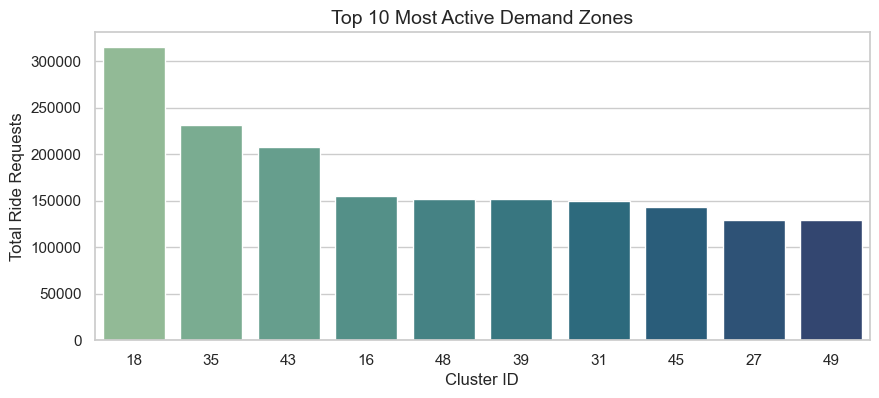

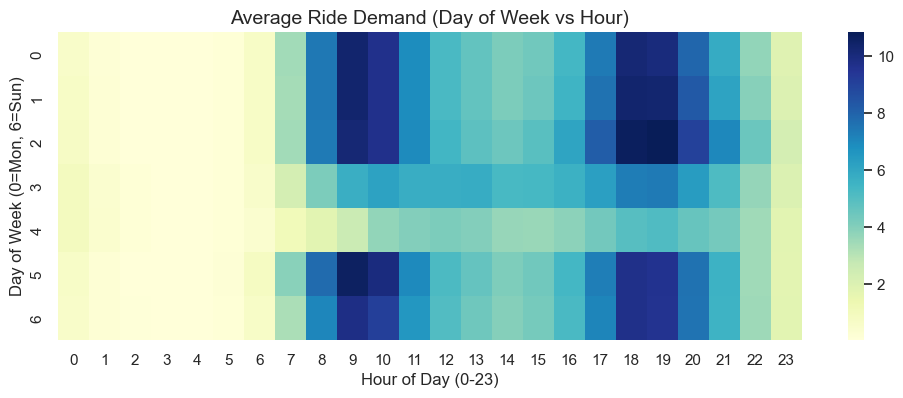

In [12]:
# Cell 3
# 1. Top 10 Busiest Zones
cluster_demand = df_prep.groupby('pickup_cluster')['request_count'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=cluster_demand.index, y=cluster_demand.values, palette='crest', order=cluster_demand.index)
plt.title('Top 10 Most Active Demand Zones', fontsize=14)
plt.xlabel('Cluster ID')
plt.ylabel('Total Ride Requests')
plt.show()

# 2. Demand Heatmap by Day and Hour
pivot_demand = df_prep.pivot_table(index='dayofweek', columns='hour', values='request_count', aggfunc='mean')
plt.figure(figsize=(12, 4))
sns.heatmap(pivot_demand, cmap='YlGnBu')
plt.title('Average Ride Demand (Day of Week vs Hour)', fontsize=14)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of Week (0=Mon, 6=Sun)')
plt.show()

Training Random Forest Model (This may take a minute)...

--- Model Performance ---
Mean Absolute Error (MAE): 1.8863 bikes
Root Mean Squared Error (RMSE): 3.0643


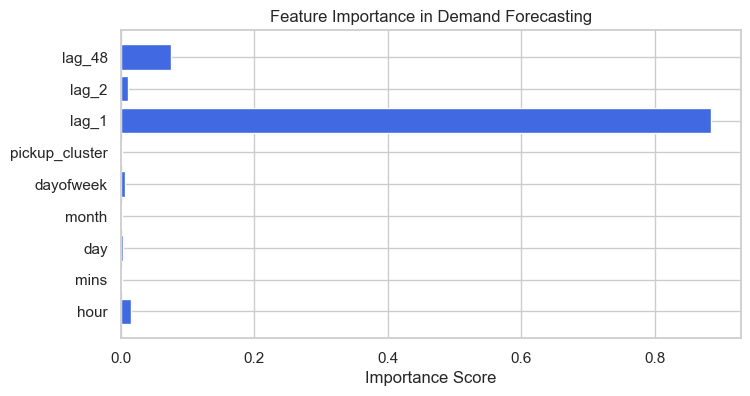

In [14]:
# Cell 4
print("Training Random Forest Model (This may take a minute)...")
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=30, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the unseen test data
preds = rf_model.predict(X_test)

# Ensure no negative predictions (demand cannot be below 0)
preds = np.maximum(preds, 0)

# Evaluate the model
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))

print(f"\n--- Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.4f} bikes")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Plot Feature Importance
plt.figure(figsize=(8, 4))
plt.barh(feature_cols, rf_model.feature_importances_, color='royalblue')
plt.title("Feature Importance in Demand Forecasting")
plt.xlabel("Importance Score")
plt.show()

In [15]:
# Cell 5
# Package the model and the feature names into a dictionary
model_payload = {
    'model': rf_model,
    'feature_names': feature_cols
}

# Save as a .pkl file in your current Jupyter directory
joblib.dump(model_payload, 'ola_model.pkl')
print("Model successfully saved as 'ola_model.pkl'. You can now close Jupyter!")

Model successfully saved as 'ola_model.pkl'. You can now close Jupyter!
